In [1]:
!pip install plotly wordcloud

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from wordcloud import WordCloud, STOPWORDS

In [11]:
data = pd.read_csv("data (1).csv")
genre_data = pd.read_csv("data_by_genres.csv")
year_data = pd.read_csv("data_by_year.csv")
artist_data = pd.read_csv("data_by_artist.csv")

In [15]:
data["decade"] = data["year"].apply(lambda x: (x // 10) * 10)

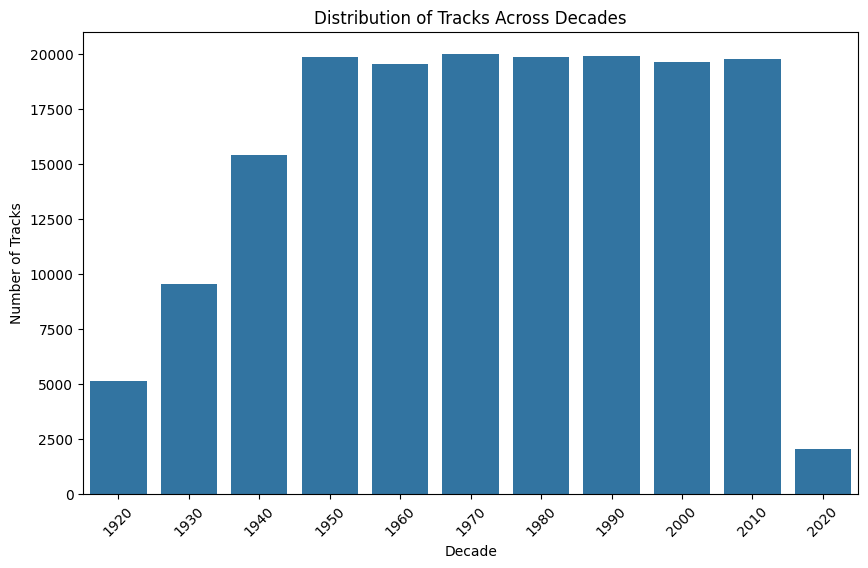

In [16]:
plt.figure(figsize=(10,6))
sns.countplot(x='decade', data=data)

plt.title('Distribution of Tracks Across Decades')
plt.xlabel('Decade')
plt.ylabel('Number of Tracks')
plt.xticks(rotation=45)
plt.show()

In [17]:
sound_features = [
    'acousticness',
    'danceability',
    'energy',
    'instrumentalness',
    'liveness',
    'valence'
]

fig = px.line(
    year_data,
    x='year',
    y=sound_features,
    title='Trend of Various Sound Features Over Decades'
)

fig.show()

In [18]:
fig = px.line(
    year_data,
    x='year',
    y='loudness',
    title='Trend of Loudness Over Decades'
)

fig.show()

In [19]:
top10_genres = genre_data.sort_values(
    by='popularity',
    ascending=False
).head(10)

fig = px.bar(
    top10_genres,
    x='genres',
    y=[
        'valence',
        'energy',
        'danceability',
        'acousticness'
    ],
    barmode='group',
    title='Trend of Various Sound Features Over Top 10 Genres'
)

fig.show()

In [20]:
stopwords = set(STOPWORDS)

comment_words = " ".join(genre_data['genres'].astype(str))

wordcloud = WordCloud(
    width=800,
    height=800,
    background_color='white',
    stopwords=stopwords,
    max_words=40,
    min_font_size=10
).generate(comment_words)

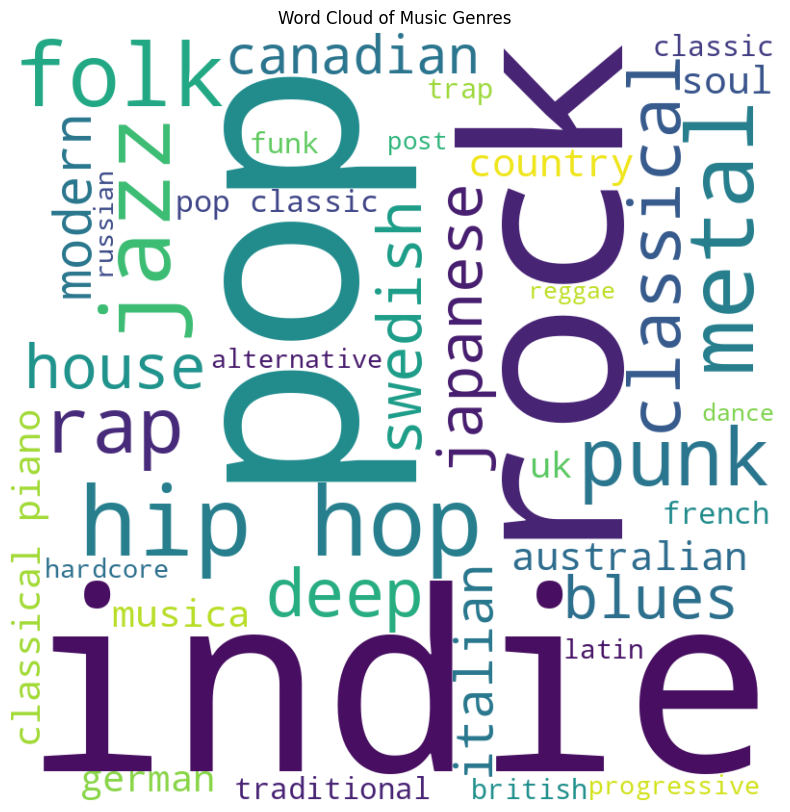

In [21]:
plt.figure(figsize=(10,10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Music Genres')
plt.show()